# <center> ***Projet : Prédiction de la Demande de Vélos en Libre-Service (Bike Sharing Demand)***

# <center> ***Exploration des données***

## Préparation des données

In [2]:
# Importation des bibliothèques
import pandas as pd
import seaborn as sns

# Chargement du jeu de données principal

df = pd.read_csv(r'C:\Users\imazi\OneDrive\Bureau\travail scolaire\programmation\Python\Machine learning\projet-bike-sharing\Data\train.csv',sep= ',')

# Affichage des premières lignes

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
# Vérifions les types de colonnes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.2 MB


On remarque que de nombreuses variables n'ont pas le type de données adéquat. Par exemple, la variable *datetime* doit être convertie vers un format temporel. Plusieurs variables devraient également être de type catégoriel. C'est notamment le cas de *weather*, dont les valeurs sont traitées comme des entiers alors qu'il s'agit d'une évaluation qualitative de la météo.

In [ ]:

# Conversion de la date dans le bon type
df['datetime'] = pd.to_datetime(df['datetime'])
# Conversion des variables season, holiday, workingday et weather en variables catégorielles
# -- Traduction des catégories des variables vers leur sens véritable 

traduction_saisons = {
 1: 'Hiver',
 2: 'Printemps',
 3: 'Été',
 4: 'Automne'
}

traduction_jours_ferier = {
 0 : 'jour non férié',
 1 : 'jour férié'
}

traduction_jours_travail = {
 0 : ' week-end/jour férié',
 1 : 'jour semaine ouvrable'
}

traduction_meteo = {
 1 : 'Dégagé',
 2 : 'Nuageux/Brouillard' ,
 3 : 'légère Pluie /Neige',
 4 : 'Fortes intempéries'
}
col_cat = ['season', 'holiday', 'workingday', 'weather']
les_dicos = [traduction_saisons,traduction_jours_ferier, traduction_jours_travail, traduction_meteo]
for col,dico in zip(col_cat,les_dicos):
 df[col] = df[col].map(dico)
 df[col] = df[col].astype('category')
# Vérifications
df.info()
traduction_jours_ferier = {
    0 : 'jour non férié',
    1 : 'jour férié'
}

traduction_jours_travail = {
    0 : ' week-end/jour férié',
    1 : 'jour semaine ouvrable'
}

traduction_meteo = {
    1 : 'Dégagé',
    2 : 'Nuageux/Brouillard' ,
    3 : 'légère Pluie /Neige',
    4 : 'Fortes intempéries'
}
col_cat = ['season', 'holiday', 'workingday', 'weather']
les_dicos = [traduction_saisons,traduction_jours_ferier, traduction_jours_travail, traduction_meteo]
for col,dico in zip(col_cat,les_dicos):
    df[col] = df[col].map(dico)
    df[col] = df[col].astype('category')
# verifications
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: category(4), datetime64[us](1), float64(3), int64(4)
memory usage: 723.4 KB


Nous observons que parmi nos variables figurent *temp* et *atemp*, correspondant respectivement à la température réelle et à la température ressentie. Ces deux indicateurs étant étroitement liés, nous allons vérifier leur niveau de dépendance à l'aide du coefficient de corrélation. Si cette forte corrélation est confirmée, nous ne conserverons qu'une seule de ces deux variables. En effet, maintenir des variables redondantes pourrait non seulement alourdir le modèle inutilement, mais aussi perturber certains algorithmes (comme la régression linéaire) qui peineraient à distinguer l'influence propre de chaque variable (problème de **multicolinéarité**).

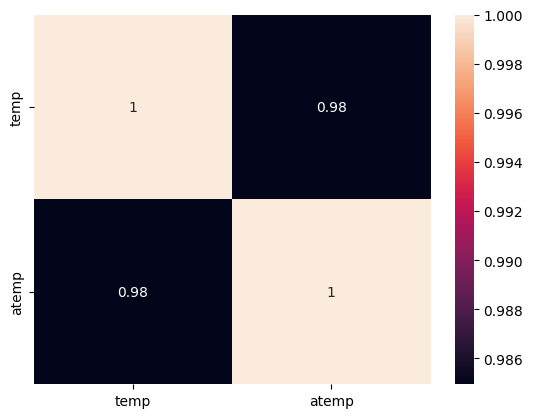

In [5]:
# On utilise la bibliothèque NumPy
import numpy as np 
# On affiche la matrice de corrélations
sns.heatmap(np.corrcoef(df['temp'],df['atemp']),annot= True,xticklabels= ['temp','atemp'],yticklabels= ['temp','atemp'])
# Notre hypothèse s'est confirmée : en effet, les variables sont corrélées à hauteur de 98 %.
# # Nous choisissons de ne garder que la variable "atemp", car elle est davantage centrée sur l'expérience utilisateur.
df = df.drop(columns='temp')


## Exploration des données 

In [ ]:
# Importation des bibliothèques
import seaborn as sns

### Impact des saisons sur le nombre de vélos loués par heure

Text(0.5, 1.0, 'La location de vélos loués en fonction des saisons')

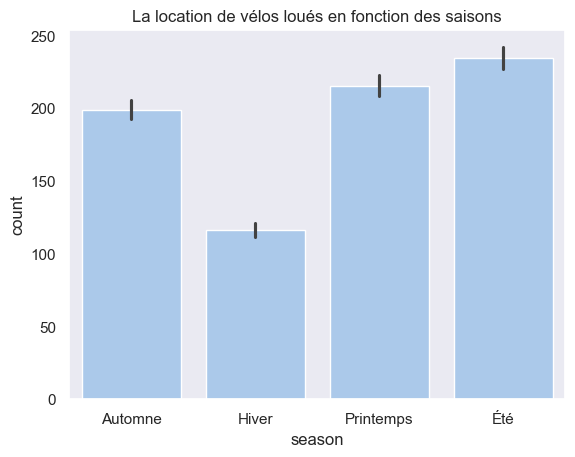

In [7]:
# Configuration esthétique
sns.set_theme(style="dark", palette="pastel")
# Affichage du diagramme à barres du nombre de vélos loués en fonction des saisons
sns.barplot(x= 'season', y = 'count',data= df).set_title("La location de vélos loués en fonction des saisons")

L'influence des saisons sur la location de vélos est manifeste. On constate qu'en hiver, les utilisateurs ont moins tendance à louer un vélo, probablement à cause des **températures basses** qui incitent à privilégier **d'autres méthodes de transport** (comme la voiture ou les transports en commun). Ensuite, les volumes de location sont comparables en automne et au printemps, bien que ce dernier soit légèrement plus fréquenté. Sans surprise, c'est en été que la demande atteint son maximum, ce qui s'explique par une météo plus clémente et l'influence des périodes de vacances. Analysons maintenant plus précisément l'impact de la température sur le nombre de locations.

Représentons donc le nombre de vélos loués en fonction de la **température ressentie**.

### Impact de la température 

Text(0.5, 1.0, 'Le nombre de vélos loués en fonction de la température ressentie')

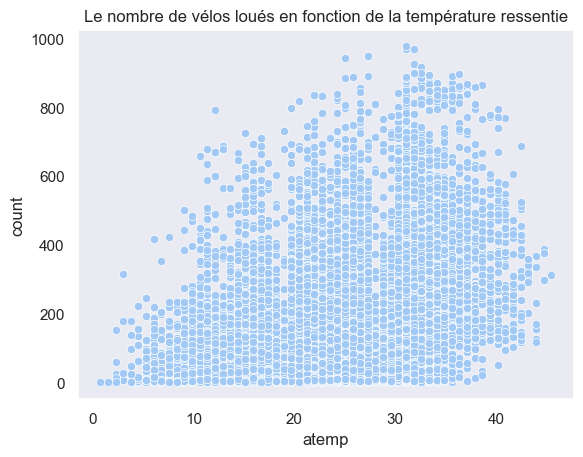

In [8]:
sns.scatterplot(x = 'atemp', y = 'count',data=df).set_title("Le nombre de vélos loués en fonction de la température ressentie")

On voit que la variable *count* croît clairement en fonction de *atemp*. Néanmoins, comme notre jeu de données contient **près de 11 000 lignes**, des centaines de points se superposent exactement au même endroit. On observe une masse compacte, mais on perd l'information de la **densité**(on ne sait pas s'il y a 5 points ou 500 points empilés au centre du nuage). Pour affiner notre analyse, essayons donc d'autres représentations.

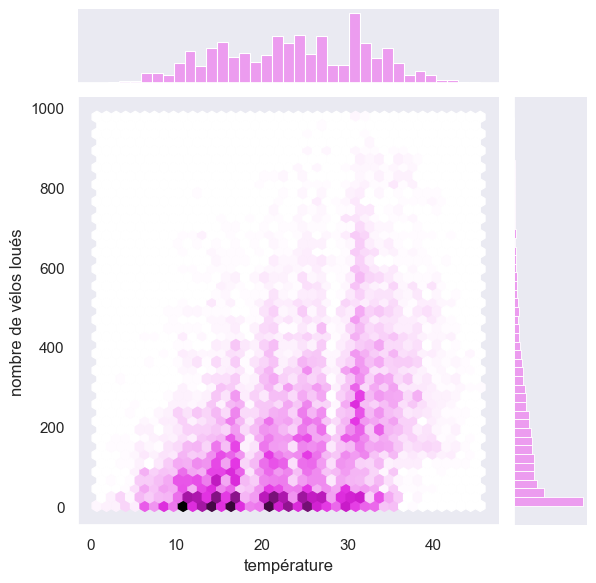

In [9]:
sns.jointplot(x='atemp', y='count', data=df, kind='hex', color = 'violet' ).set_axis_labels("température","nombre de vélos loués")

L'analyse visuelle croisant la température ressentie (*atemp*) et le volume de locations (*count*) confirme notre hypothèse initiale : il existe une corrélation positive claire entre la chaleur et l'utilisation des vélos. Plus la température est clémente, plus la demande grimpe.

Cependant, l'utilisation d'un graphique de densité révèle deux nuances majeures que l'on ne voyait pas avec un simple nuage de points. Premièrement, on observe un effet de saturation autour de 35°C : au-delà de ce seuil, la chaleur devient étouffante et les locations ont tendance à stagner ou à chuter. Deuxièmement, la très forte concentration de données (la zone sombre) au bas du graphique nous rappelle que, quelle que soit la température idéale de la journée, une grande majorité des heures (les nuits et heures creuses) enregistre un nombre de locations proche de zéro.

<Axes: >

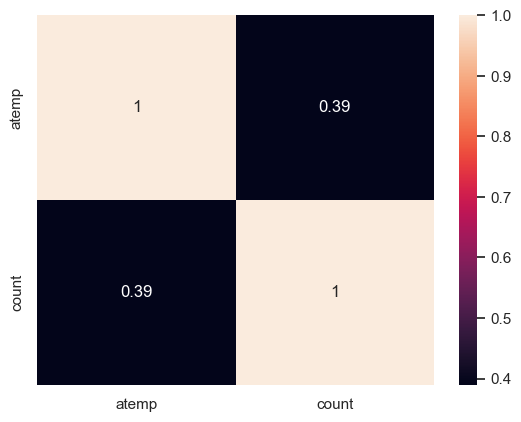

In [10]:
sns.heatmap(np.corrcoef(df['atemp'],df['count']),annot = True, xticklabels=['atemp','count'], yticklabels=['atemp','count'] )

Bien que l'on puisse s'attendre à un coefficient de corrélation plus élevé, on constate qu'il existe une réelle corrélation positive entre le nombre de locations de vélos et l'augmentation de la température. De plus, le fait que le coefficient de corrélation ne soit "que" de 0,39 montre que la variable *count* ne s'explique pas uniquement par la température. En effet, une température idéale ne garantit pas la location d'un vélo ; on peut aisément imaginer que cela n'a que peu d'impact à 3 h 00 du matin.

### Impact de la météo

On va s'intéresser à l'impact de la variable météo (*weather*) sur la location de vélos.

Text(0.5, 1.0, 'La location de vélos en fonction de la météo.')

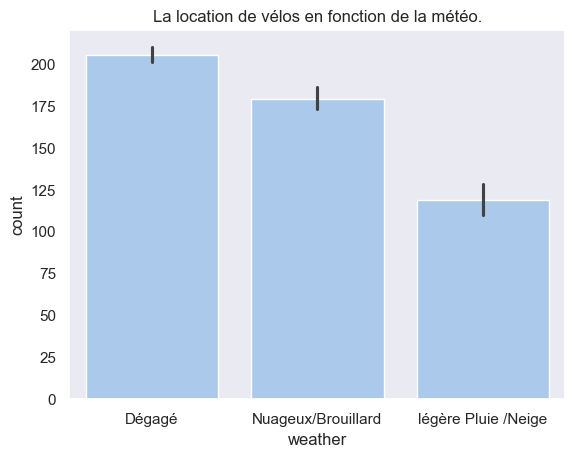

In [22]:
sns.barplot(x = 'weather', y = 'count',data = df).set_title("La location de vélos en fonction de la météo.")

En premier lieu, il nous semble évident que si la météo est dégagée, plus de personnes sont susceptibles de prendre le vélo. De même, on note qu'en moyenne, 180 vélos sont loués sous un ciel relativement nuageux. À notre grande surprise, il semble qu'il y ait plus de vélos loués lors de fortes intempéries que lors de légères pluies. Cela nous semble vraiment suspect. Une raison pouvant expliquer cela est le mode de fonctionnement du diagramme à barres, qui calcule la moyenne des vélos loués pour chaque modalité de la variable *weather*. Imaginons qu'il n'y ait eu qu'une seule et unique heure de "Fortes intempéries" pendant les deux ans d'historique de Washington D.C., et que par hasard, ce fût à 18 h un mardi (l'heure où tout le monde quitte le bureau en urgence pour se mettre à l'abri) ? La moyenne de cette catégorie ne serait basée que sur cette heure unique, elle serait donc artificiellement élevée. Regardons la distribution de nos observations en fonction de la météo.

In [12]:
df['weather'].value_counts()

weather
Dégagé                 7192
Nuageux/Brouillard     2834
légère Pluie /Neige     859
Fortes intempéries        1
Name: count, dtype: int64

In [13]:
df[df['weather'] == 'Fortes intempéries']

,datetime,season,holiday,workingday,weather,atemp,humidity,windspeed,casual,registered,count
5631,2012-01-09 18:00:00,Hiver,jour non férié,jour semaine ouvrable,Fortes intempéries,11.365,86,6.0032,6,158,164


Notre hypothèse se confirme : il n'y a qu'une seule observation s'étant déroulée lors de fortes intempéries (sûrement de fortes pluies d'hiver au vu de l'humidité de 86 %) durant laquelle 164 vélos ont été loués. Cette donnée unique semble perturber nos analyses ; on pourrait choisir de la supprimer ou de l'ajouter à une autre catégorie. Ici, au vu de notre volume de données, se débarrasser de cette ligne semble être la meilleure solution.

In [14]:
df = df[df['weather'] != 'Fortes intempéries']
# On supprime la modalité vide à présent
df['weather'] = df['weather'].cat.remove_unused_categories()

Text(0.5, 1.0, 'Le nombre de vélos loués en fonction de la météo.')

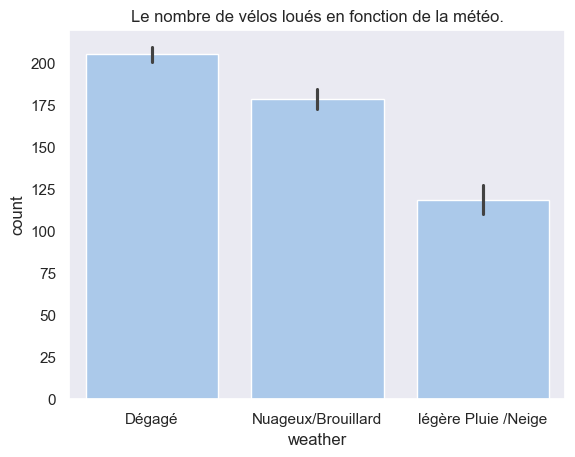

In [23]:
# On réaffiche notre barplot
sns.barplot(x = 'weather', y = 'count',data = df).set_title('Le nombre de vélos loués en fonction de la météo.')

On observe que plus la météo est dégagée, plus les personnes ont tendance à louer des vélos.

### Importance de la date

On sait que les données sont récoltées toutes les heures entre 2011 et 2012. On va « découper » notre variable *datetime* afin de répondre aux questions suivantes : 

* Existe-t-il des heures où l'on loue plus de vélos (notion d'heures de pointe) ?
* Nous avons la variable *season*, mais pouvons-nous être certains que le volume de vélos loués est uniforme durant toute la saison ou cela dépend-il du mois ?
* La récolte de données a duré deux ans, mais il est possible que durant la seconde année, les personnes aient loué plus de vélos ; est-ce le cas ?

In [16]:
# On crée donc 3 autres variables : hour, year, month
df['hour'] = df['datetime'].dt.hour
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
# Vérification de la création des variables.
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'hour',
       'year', 'month'],
      dtype='str')

Text(0.5, 1.0, "Nombre de vélos loués en fonction de l'heure")

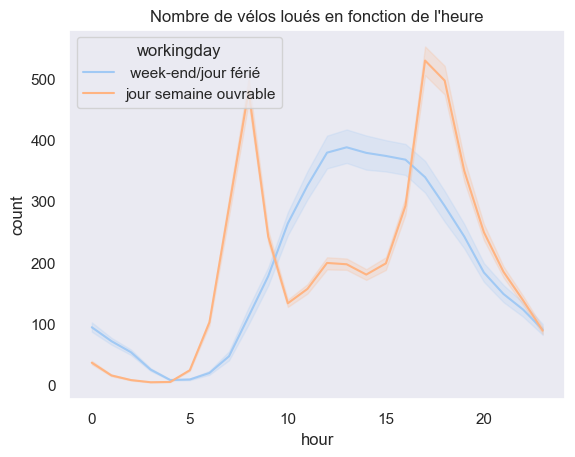

In [24]:
# On va créer la courbe des locations de vélos en fonction de l'heure, en distinguant les jours de travail, les week-ends et les jours fériés
sns.lineplot(x = 'hour', y = 'count', data = df, hue= 'workingday').set_title("Nombre de vélos loués en fonction de l'heure")

L'analyse temporelle des locations révèle une dichotomie claire selon le type de journée. En semaine (jours ouvrés), la courbe illustre un phénomène classique de trajets domicile-travail, caractérisé par deux pics d'affluence très marqués aux heures de pointe (8h-9h et 17h-18h). À l'inverse, durant les week-ends et jours fériés, la dynamique change radicalement : la demande forme une courbe en cloche atteignant son apogée en début d'après-midi, ce qui suggère une transition vers un usage principalement récréatif, sportif ou touristique.

Répondons maintenant à notre seconde question : **y a-t-il une différence réelle du nombre de locations suivant les mois dans une même saison ?** *Par exemple :* un doux début d'octobre et un glacial mois de décembre.

Text(0.5, 1.0, 'Évolution mensuelle des locations : au-delà des saisons')

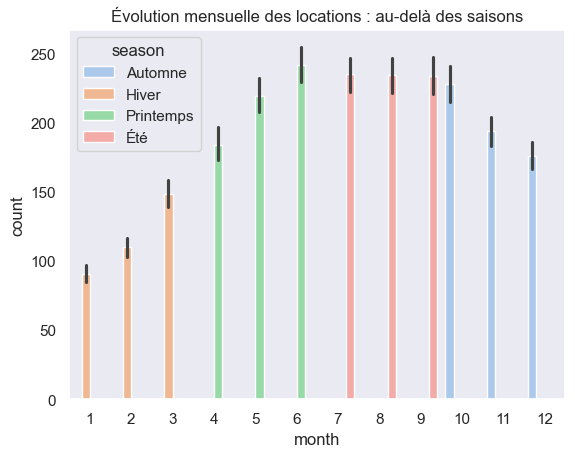

In [18]:
sns.barplot(x ='month', y= 'count',data = df, hue = 'season').set_title("Évolution mensuelle des locations : au-delà des saisons")

L'analyse du volume de locations par mois révèle que la notion de saison est insuffisante pour capter avec précision le comportement des utilisateurs. Au sein d'une même saison (représentée par les différentes couleurs), nous observons des variations significatives. Par exemple, au printemps (en vert), la demande connaît une croissance spectaculaire entre avril et juin. De même, en automne (en bleu), la chute est drastique entre octobre et décembre.

Globalement, le volume de locations suit une courbe en cloche (une distribution presque normale) centrée sur l'été, avec le mois de juin qui s'impose comme le champion incontesté de l'année. Cette dynamique souligne la nécessité de conserver la variable 'mois' (*month*) dans notre modèle prédictif pour lui fournir une meilleure précision sur les transitions climatiques intersaisonnières.

Répondons maintenant à la dernière question de notre phase exploratoire : **existe-t-il un plus grand engouement pour la location de vélos en 2012 par rapport à 2011 ?**

Text(0.5, 1.0, 'Nombre de vélos loués chaque année.')

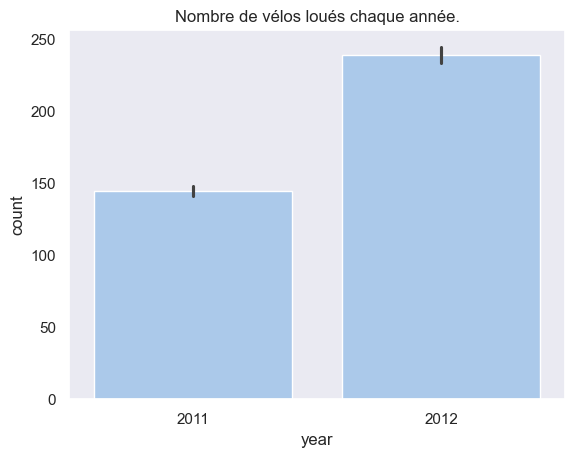

In [25]:
sns.barplot(x= 'year',y = 'count',data= df).set_title("Nombre de vélos loués chaque année.")

In [20]:
df['year'].value_counts()

year
2012    5463
2011    5422
Name: count, dtype: int64

Il semble en effet qu'il y ait un essor du nombre de vélos loués en 2012 par rapport à 2011 (environ 240 contre 150). Cette différence est néanmoins à nuancer, car il existe un écart de 41 observations entre l'année 2012 et 2011 (voir commande `value_counts` ci-dessus), ce qui ne suffit toutefois pas à justifier la différence nette entre les deux années.

## 🎯 Conclusion de l'Analyse Exploratoire des Données (EDA)

Au terme de cette phase d'exploration, nous avons acquis une compréhension approfondie de la dynamique de location de vélos et préparé un jeu de données robuste pour la modélisation.

### 1. Comportement des utilisateurs et météo
    
La demande est fortement corrélée aux conditions climatiques. Les utilisateurs privilégient les températures clémentes, avec un pic d'utilisation autour de 25-30 °C ressentis, suivi d'une baisse lors des chaleurs extrêmes. Les intempéries freinent logiquement les locations ; l'unique observation liée à une violente tempête a d'ailleurs été écartée pour ne pas fausser le modèle. Afin d'éviter la multicolinéarité, nous avons conservé uniquement la température ressentie (*atemp*), plus représentative du choix humain que la température brute (*temp*).

### 2. Dynamiques temporelles et usages 
   
Le *Feature Engineering* sur la date nous a permis de révéler des tendances cruciales :
* **Usage journalier :** une distinction claire existe entre les jours ouvrés (caractérisés par des trajets domicile-travail avec des pics à 8 h et 17 h) et les week-ends (caractérisés par un usage de loisir l'après-midi).
* **Saisonnalité fine :** le mois de juin est la période la plus faste de l'année, démontrant que le volume de locations varie fortement à l'intérieur même d'une saison.
* **Croissance globale :** l'année 2012 marque un essor commercial majeur par rapport à 2011, avec une forte augmentation moyenne du nombre de locations.

In [21]:
# On sauvegarde nos données dans un nouveaux fichier csv
df.to_csv('train_clean.csv',index= False)